In [1]:
# this notebook contains a lot of ML training/testing/validation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import boto3
import pyarrow.parquet as pq
import seaborn as sns
import lightgbm as lgb

# sklearn
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score, accuracy_score, confusion_matrix, classification_report, auc
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from sklearn.inspection import permutation_importance

In [2]:
s3 = boto3.client('s3')
df = pd.read_parquet('s3://processed-data-809918852303-us-east-1-an/maxt_merged_df_7days_FULL.parquet')

In [3]:
df

,public_zone,date,week,forecast_day,state,zone_id,name,model_run_date,maxt_value_nbm,maxt_value_prism,60daywindow_prism,7daywindow_prism,nbm_minus_obs,nbm_minus_obs_window_60d,nbm_minus_obs_window_7d
0,1,2020-10-20,43,1,AL,001,Lauderdale,2020-10-20,80.592466,80.438460,79.339964,73.473508,0.154006,1.252502,7.118957
1,1,2020-10-21,43,1,AL,001,Lauderdale,2020-10-21,81.503425,81.583053,79.380602,74.445798,-0.079628,2.122823,7.057627
2,1,2020-10-21,43,2,AL,001,Lauderdale,2020-10-20,81.102740,81.583053,79.380602,74.445798,-0.480313,1.722138,6.656942
3,1,2020-10-22,43,1,AL,001,Lauderdale,2020-10-22,81.886986,82.355829,79.372306,74.662086,-0.468843,2.514681,7.224900
4,1,2020-10-22,43,2,AL,001,Lauderdale,2020-10-21,81.688356,82.355829,79.372306,74.662086,-0.667473,2.316051,7.026270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52660295,3850,2026-07-17,29,3,WY,199,Sheridan Foothills,2026-07-15,95.678788,91.396461,78.531191,97.448493,4.282327,17.147596,-1.769705
52660296,3850,2026-07-17,29,4,WY,199,Sheridan Foothills,2026-07-14,95.527273,91.396461,78.531191,97.448493,4.130812,16.996081,-1.921220
52660297,3850,2026-07-17,29,5,WY,199,Sheridan Foothills,2026-07-13,94.435152,91.396461,78.531191,97.448493,3.038690,15.903960,-3.013342
52660298,3850,2026-07-17,29,6,WY,199,Sheridan Foothills,2026-07-12,96.001212,91.396461,78.531191,97.448493,4.604751,17.470021,-1.447281


In [4]:
df = df.drop(columns=['state', 'zone_id', 'name', 'model_run_date'])
df = df.sort_values(by="date").reset_index(drop=True)

In [5]:
# extracting year for each row
df['date'] = pd.to_datetime(df['date'])
df['day_number'] = df['date'].dt.dayofyear
df['year'] = df['date'].dt.year

In [6]:
# get the max week present in the data for each year
max_weeks = df.groupby('year')['week'].transform('max')

# if not 52 or 53 default to 52
max_weeks = np.where(max_weeks.isin([52, 53]), max_weeks, 52)

# decompose discrete week into cont. sin/cos component
df['week_sin'] = np.sin(2 * np.pi * df['week'] / max_weeks)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / max_weeks)

df = df.drop(columns=['year'])

In [8]:
#create boolean masks for differences outside of 2°F, 3°F, 4°F, and 5°F 
mask_2F = (df['nbm_minus_obs'] <= -2)
df['outside_-2F'] = mask_2F

mask_3F = (df['nbm_minus_obs'] <= -3)
df['outside_-3F'] = mask_3F

mask_4F = (df['nbm_minus_obs'] <= -4)
df['outside_-4F'] = mask_4F

mask_5F = (df['nbm_minus_obs'] <= -5)
df['outside_-5F'] = mask_5F

mask_2F = (df['nbm_minus_obs'] >= 2)
df['outside_2F'] = mask_2F

mask_3F = (df['nbm_minus_obs'] >= 3)
df['outside_3F'] = mask_3F

mask_4F = (df['nbm_minus_obs'] >= 4)
df['outside_4F'] = mask_4F

mask_5F = (df['nbm_minus_obs'] >= 5)
df['outside_5F'] = mask_5F

In [9]:
df

,public_zone,date,week,forecast_day,maxt_value_nbm,maxt_value_prism,60daywindow_prism,7daywindow_prism,nbm_minus_obs,nbm_minus_obs_window_60d,...,week_sin,week_cos,outside_-2F,outside_-3F,outside_-4F,outside_-5F,outside_2F,outside_3F,outside_4F,outside_5F
0,1,2020-10-20,43,1,80.592466,80.438460,79.339964,73.473508,0.154006,1.252502,...,-0.92669,0.375828,False,False,False,False,False,False,False,False
1,2567,2020-10-20,43,1,59.605263,62.456438,72.937317,59.564812,-2.851175,-13.332054,...,-0.92669,0.375828,True,False,False,False,False,False,False,False
2,2568,2020-10-20,43,1,59.871429,63.803503,72.346980,59.581230,-3.932074,-12.475551,...,-0.92669,0.375828,True,True,False,False,False,False,False,False
3,2569,2020-10-20,43,1,59.368159,63.217943,71.618797,59.168277,-3.849784,-12.250638,...,-0.92669,0.375828,True,True,False,False,False,False,False,False
4,2570,2020-10-20,43,1,59.676768,62.194178,70.704480,58.512949,-2.517410,-11.027713,...,-0.92669,0.375828,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52660295,2566,2026-07-17,29,7,86.994475,88.589921,81.078570,87.107737,-1.595446,5.915905,...,-0.354605,-0.935016,False,False,False,False,False,False,False,False
52660296,2567,2026-07-17,29,1,90.587719,85.832339,79.501355,85.685292,4.755380,11.086365,...,-0.354605,-0.935016,False,False,False,False,True,True,True,False
52660297,2567,2026-07-17,29,2,91.070175,85.832339,79.501355,85.685292,5.237837,11.568821,...,-0.354605,-0.935016,False,False,False,False,True,True,True,True
52660298,2563,2026-07-17,29,6,89.698324,89.483071,81.769605,88.595938,0.215253,7.928719,...,-0.354605,-0.935016,False,False,False,False,False,False,False,False


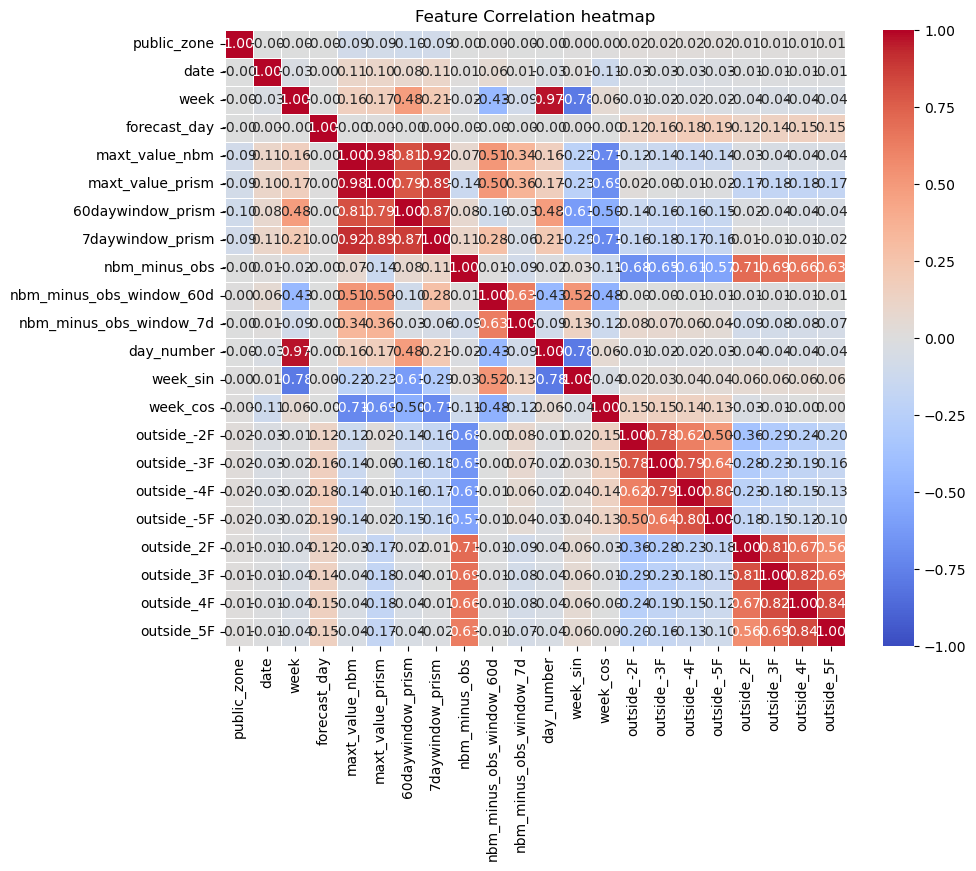

In [11]:
corr_matrix = df.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation heatmap")
plt.show()

In [10]:
# defining proportions!!!
train_ratio = 0.72
val_ratio = 0.14

total_rows = len(df)
val_split_idx = int(total_rows * train_ratio)
test_split_idx = int((total_rows * (train_ratio + val_ratio)))

val_cutoff = df.iloc[[df.index[val_split_idx]]]
val_cutoff = val_cutoff['date'].iloc[0].date()
val_cutoff = pd.to_datetime(val_cutoff)

test_cutoff = df.iloc[[df.index[test_split_idx]]]
test_cutoff = test_cutoff['date'].iloc[0].date()
test_cutoff = pd.to_datetime(test_cutoff)

#time based splitting here
train_df = df[df['date'] <= val_cutoff]
val_df = df[df['date'] <= test_cutoff]
val_df = val_df[val_df['date'] > val_cutoff]
test_df = df[df['date'] > test_cutoff]

print(f"Train window: '{train_df['date'].min()}' to '{train_df['date'].max()}'")
print(f"Val window:   '{val_df['date'].min()}' to '{val_df['date'].max()}'")
print(f"Test window:  '{test_df['date'].min()}' to '{test_df['date'].max()}'")

Train window: '2020-10-20 00:00:00' to '2025-01-13 00:00:00'
Val window:   '2025-01-14 00:00:00' to '2025-10-14 00:00:00'
Test window:  '2025-10-15 00:00:00' to '2026-07-17 00:00:00'


In [11]:
num_list = [-2, 2, -3, 3, -4, 4, -5, 5]

for i in num_list:
    string=f"outside_{i}F"
    mask = (train_df.loc[train_df[string]==True, 'nbm_minus_obs_window_7d'])
    print(f"train_df vals outside {i}F: {mask.count()/len(train_df[string])*100:.3f}%")
    
    mask = (val_df.loc[val_df[string]==True, 'nbm_minus_obs_window_7d'])
    print(f"val_df vals outside {i}F: {mask.count()/len(val_df[string])*100:.3f}%")
    
    mask = (test_df.loc[test_df[string]==True, 'nbm_minus_obs_window_7d'])
    print(f"test_years vals outside {i}F: {mask.count()/len(test_df[string])*100:.3f}%\n")

train_df vals outside -2F: 29.621%
val_df vals outside -2F: 27.028%
test_years vals outside -2F: 28.896%

train_df vals outside 2F: 24.304%
val_df vals outside 2F: 23.321%
test_years vals outside 2F: 25.536%

train_df vals outside -3F: 20.503%
val_df vals outside -3F: 17.979%
test_years vals outside -3F: 20.074%

train_df vals outside 3F: 17.364%
val_df vals outside 3F: 16.500%
test_years vals outside 3F: 18.693%

train_df vals outside -4F: 13.954%
val_df vals outside -4F: 11.852%
test_years vals outside -4F: 13.852%

train_df vals outside 4F: 12.453%
val_df vals outside 4F: 11.871%
test_years vals outside 4F: 13.745%

train_df vals outside -5F: 9.454%
val_df vals outside -5F: 7.842%
test_years vals outside -5F: 9.645%

train_df vals outside 5F: 8.992%
val_df vals outside 5F: 8.635%
test_years vals outside 5F: 10.183%



In [20]:
# Input features
features = [
#    'public_zone',                            # 1-3850
    'week_sin',
    'week_cos',
    'forecast_day',                           # 1-7
    'nbm_minus_obs_window_7d',                # 7-day averaged window
    'nbm_minus_obs_window_60d'                # 60-day averaged window
]

target_columns = [
    'outside_-2F',
    'outside_2F', 
    'outside_-3F',
    'outside_3F',
    'outside_-4F', 
    'outside_4F',
    'outside_-5F',
    'outside_5F']

# getting features to the right data types for LGBM
#df['public_zone']              = df['public_zone'].astype('category')
df['week_sin']                 = df['week_sin'].astype(float)
df['week_cos']                 = df['week_cos'].astype(float)
df['forecast_day']             = df['forecast_day'].astype('category')
df['nbm_minus_obs_window_7d']  = df['nbm_minus_obs_window_7d'].astype(float)
df['nbm_minus_obs_window_60d'] = df['nbm_minus_obs_window_60d'].astype(float)


In [21]:
def create_multiclass_target(error_series, threshold=2.0):
    conditions = [
        (error_series <= -threshold),                  #underforecast
        (error_series >= threshold)                    # overforecast
    ]
    choices = [2, 1]
    return np.select(conditions, choices, default=0) #we're good

y_train = create_multiclass_target(train_df['nbm_minus_obs'], 5)
y_val = create_multiclass_target(val_df['nbm_minus_obs'], 5)
y_test = create_multiclass_target(test_df['nbm_minus_obs'], 5)


LightGBM

In [28]:
class_num = 3

X_train = train_df[features]
y_train = create_multiclass_target(train_df['nbm_minus_obs'], threshold=class_num)
X_val = val_df[features]
y_val = create_multiclass_target(val_df['nbm_minus_obs'], threshold=class_num)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weight_dict = dict(zip(classes, weights))
class_weight_dict # class weights available !!!

{np.int64(0): np.float64(0.5364808961858925),
 np.int64(1): np.float64(1.9196687238532646),
 np.int64(2): np.float64(1.6258113428303476)}

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.113073 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 619
[LightGBM] [Info] Number of data points in the train set: 37918650, number of used features: 5
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[56]	valid_0's auc_mu: 0.68968
Overall Model Accuracy: 0.4974

--- LIGHTGBM VALIDATION RESULTS ---
                   precision    recall  f1-score   support

  Decent Forecast       0.79      0.52      0.62   4838298
 Off overforecast       0.24      0.49      0.32   1218389
Off underforecast       0.33      0.43      0.37   1327613

         accuracy                           0.50   

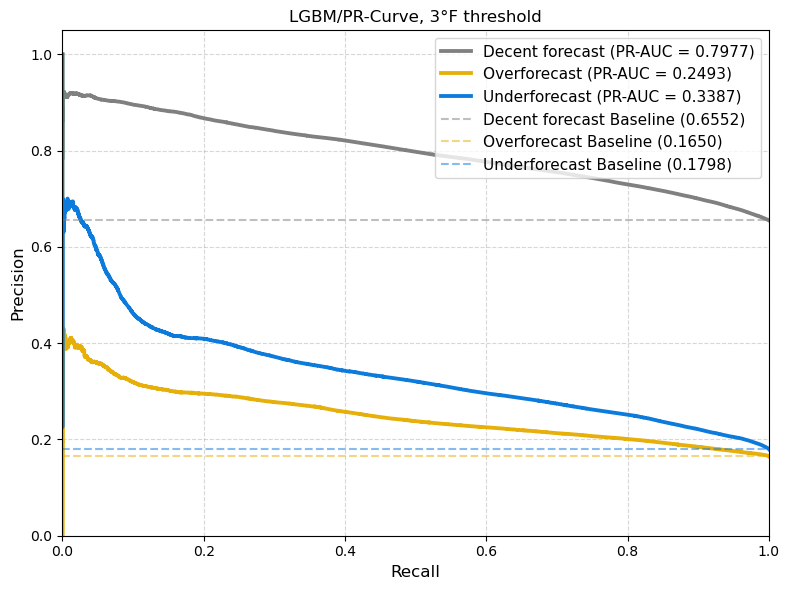

In [29]:
lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    metric='auc_mu',
    num_class=3,
    num_leaves=45,
    n_estimators=1000,       
    learning_rate=0.05,
    max_depth=12,   
    min_child_samples=500,
    max_bins=255,
    max_bin_by_feature=[52, 52, 7, 255, 255],
    class_weight='balanced',
    n_jobs=-1,          
    random_state=42,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
)

y_val_pred = lgb_model.predict(X_val)
y_val_prob = lgb_model.predict_proba(X_val)

acc = accuracy_score(y_val, y_val_pred)
print(f"Overall Model Accuracy: {acc:.4f}")

print("\n--- LIGHTGBM VALIDATION RESULTS ---")
print(classification_report(y_val, y_val_pred, target_names=['Decent Forecast', 'Off overforecast', 'Off underforecast']))

classes = [0, 1, 2]
colors = ['grey', '#e6af09', '#0c7bdc', 'grey']
target_names = ['Decent forecast', 'Overforecast', 'Underforecast']
y_val_binarized = label_binarize(y_val, classes=classes)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(target_names):
    precision, recall, _ = precision_recall_curve(y_val_binarized[:, i], y_val_prob[:, i])
    
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f'{class_name} (PR-AUC = {pr_auc:.4f})', linewidth=2.75, color=colors[i])

# baseline reference line
for i in range(len(classes)):
    prevalence = y_val_binarized[:, i].mean()
    plt.axhline(
        y=prevalence, 
        linestyle='--', 
        color=colors[i],
        alpha=0.5,
        label=f'{target_names[i]} Baseline ({prevalence:.4f})'
    )
    
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'LGBM/PR-Curve, {class_num}°F threshold')
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
#plt.savefig(f'maxT-{class_num}F-lgbm-pr-auc-final.png')
#plt.savefig(f'with_7daywindow_{class_num}F-maxT-lgbm-pr-auc.png')
plt.show()

In [30]:
# get both importance types
split_importance = lgb_model.booster_.feature_importance(importance_type='split') # adjust 'model' variable name to your fitted LGBM classifier
gain_importance = lgb_model.booster_.feature_importance(importance_type='gain')
feature_names = X_train.columns

# build combined df
df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Split (Frequency)': split_importance,
    'Gain (Impact)': gain_importance
})

# normalize them to percentages so easy to compare
df_imp['Split %'] = (df_imp['Split (Frequency)'] / df_imp['Split (Frequency)'].sum()) * 100
df_imp['Gain %'] = (df_imp['Gain (Impact)'] / df_imp['Gain (Impact)'].sum()) * 100

# sort by gain to see what drives predictions, public_zone should be most of split however
df_imp = df_imp.sort_values(by='Gain %', ascending=False)
print(df_imp[['Feature', 'Gain %', 'Split %']].to_string(index=False))

                 Feature    Gain %   Split %
            forecast_day 32.829583  9.023268
                week_cos 23.235321 18.208874
 nbm_minus_obs_window_7d 20.584502 20.643939
                week_sin 16.466473 32.629870
nbm_minus_obs_window_60d  6.884121 19.494048


Final Test Model Accuracy: 0.4449

--- FINAL LIGHTGBM TEST SET RESULTS ---
                   precision    recall  f1-score   support

  Decent Forecast       0.76      0.42      0.54   4505121
 Off overforecast       0.27      0.43      0.33   1375309
Off underforecast       0.30      0.54      0.39   1476920

         accuracy                           0.44   7357350
        macro avg       0.44      0.46      0.42   7357350
     weighted avg       0.58      0.44      0.47   7357350



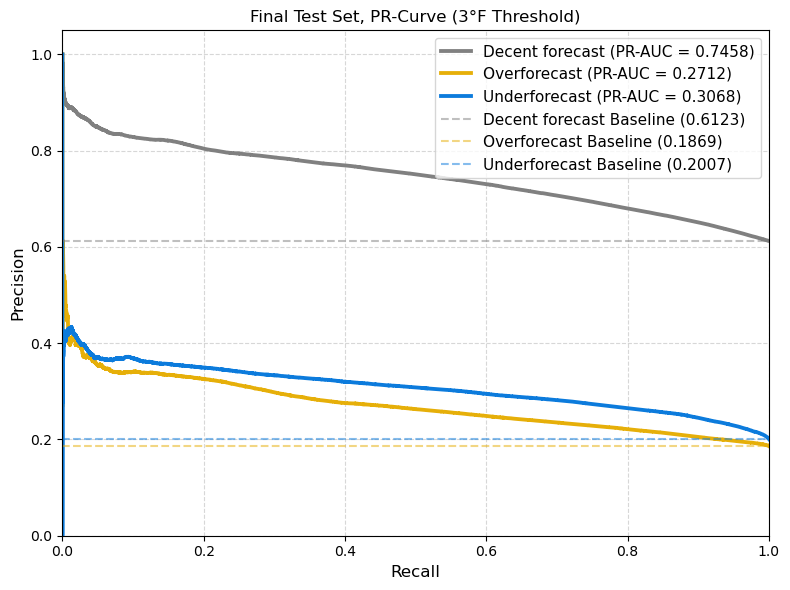

In [31]:
X_test = test_df[features]
y_test = create_multiclass_target(test_df['nbm_minus_obs'], threshold=class_num)

y_test_pred = lgb_model.predict(X_test)
y_test_prob = lgb_model.predict_proba(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
print(f"Final Test Model Accuracy: {test_acc:.4f}")

print("\n--- FINAL LIGHTGBM TEST SET RESULTS ---")
print(classification_report(y_test, y_test_pred, target_names=['Decent Forecast', 'Off overforecast', 'Off underforecast']))


###############################################FINAL LIGHTGBM TEST SET RESULTS

classes = [0, 1, 2]
colors = ['grey', '#e6af09', '#0c7bdc', 'grey']
target_names = ['Decent forecast', 'Overforecast', 'Underforecast']
y_test_binarized = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(target_names):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_test_prob[:, i])
    
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f'{class_name} (PR-AUC = {pr_auc:.4f})', linewidth=2.75, color=colors[i])

# baseline reference line
for i in range(len(classes)):
    prevalence = y_test_binarized[:, i].mean()
    plt.axhline(
        y=prevalence, 
        linestyle='--', 
        color=colors[i],
        alpha=0.5,
        label=f'{target_names[i]} Baseline ({prevalence:.4f})'
    )
    
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'Final Test Set, PR-Curve ({class_num}°F Threshold)')
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
#plt.savefig(f'maxT-{class_num}F-lgbm-TEST-final')
#plt.savefig(f'with_7daywindow_{class_num}F-maxT-test-lgbm-pr-auc.png')
plt.show()

In [32]:
# save trained model to reuse later when testing on NBMv5.0
lgb_model.booster_.save_model(f'lgbm_production_model_maxt_{class_num}F_window_nozones.txt')
# print("model saved")